# Baselines — bicubic, BCSD, Lasso

Three classical baselines for MODIS LST downscaling (4 km → 1 km) on the
Colorado Front Range, evaluated on the spatial+temporal holdout.

* **Bicubic** — pure interpolation, no training.
* **BCSD** (Bias Correction Spatial Disaggregation) — per-pixel monthly
  climatology bias correction. Standard climate-downscaling baseline.
* **Lasso** — single global L1-regularized linear model with HR covariates
  (NDVI, DEM, LULC one-hot) plus the bicubic-upsampled LR LST.

Metrics are computed only over each split's spatial blocks (val/test
pixels are spatially disjoint from train pixels), and only over pixels
with valid (cloud-free, QC-pass) MODIS LST.


## 0 — Setup

In [13]:
# Colab: install deps. Local: skip if already installed.
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rasterio geopandas h5py huggingface_hub scikit-learn


In [14]:
# Pull the model + dataloader code. On Colab we clone; locally we assume cwd is the repo.
import os, sys
if IN_COLAB:
    if not os.path.isdir('downscaling'):
        !git clone -q https://github.com/fresleven/downscaling.git
    %cd downscaling
    sys.path.insert(0, '.')
else:
    # Add repo root to path (notebook lives in notebooks/colabs/)
    sys.path.insert(0, os.path.abspath('../..'))


In [15]:
from huggingface_hub import snapshot_download
DATA_ROOT = 'data'
snapshot_download(
    repo_id='akhot2/downscaling',
    repo_type='dataset',
    local_dir=DATA_ROOT,
)


Fetching 773 files:   0%|          | 0/773 [00:00<?, ?it/s]

'/home/fresleven/uiuc/downscaling/notebooks/colabs/data'

## 1 — Datasets

In [16]:
from model.dataset import DownscalingDataset, get_dataloaders

train_ds = DownscalingDataset(root=DATA_ROOT, split='train', download=False)
val_ds   = DownscalingDataset(root=DATA_ROOT, split='val',   download=False)
test_ds  = DownscalingDataset(root=DATA_ROOT, split='test',  download=False)

print(f'Samples — train: {len(train_ds)} ({len(train_ds.dates)} dates × {len(train_ds.split_blocks)} blocks)')
print(f'           val:  {len(val_ds)},  test: {len(test_ds)}')
print(f'HR shape: {train_ds.hr_shape},  LR shape: {train_ds.lr_shape}')


Samples — train: 2300 (230 dates × 10 blocks)
           val:  536,  test: 2464
HR shape: (112, 87),  LR shape: (28, 22)


## 2 — Metrics

In [17]:
import numpy as np
from model.dataset import read_modis_lst, reproject_to, REF_CRS
from rasterio.enums import Resampling as _Resampling


def masked_metrics(pred, target, mask):
    pred = np.asarray(pred); target = np.asarray(target); mask = np.asarray(mask, dtype=bool)
    rmses, maes, biases, r2s = [], [], [], []
    for i in range(len(pred)):
        m = mask[i]
        if not m.any(): continue
        p = pred[i][m]; t = target[i][m]
        valid = np.isfinite(p) & np.isfinite(t)
        p = p[valid]; t = t[valid]
        if len(p) == 0: continue
        d = p - t
        rmses.append(np.sqrt(np.mean(d ** 2)))
        maes.append(np.mean(np.abs(d)))
        biases.append(np.mean(d))
        ss_res = np.sum(d ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2s.append(1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan'))
    def _m(v): return float(np.nanmean(v)) if v else float('nan')
    return {'RMSE': _m(rmses), 'MAE': _m(maes), 'Bias': _m(biases),
            'R2': _m(r2s), 'n_scenes': len(rmses)}


def collect_full_scenes(ds):
    """Load full HR scenes (not blocks) for baseline evaluation.

    Iterates over dates directly — each MODIS file is read once, not once per block.
    valid_mask = finite LST AND pixel is in this split's spatial blocks.
    """
    H, W = ds.hr_shape
    n = len(ds.dates)
    hr    = np.full((n, H, W), np.nan, dtype=np.float32)
    lr    = np.full((n, *ds.lr_shape), np.nan, dtype=np.float32)
    vmask = np.zeros((n, H, W), dtype=bool)
    dmask = np.zeros((n, H, W), dtype=bool)
    ndvi  = np.zeros((n, H, W), dtype=np.float32)

    for i, (date, path) in enumerate(ds.dates):
        lst, tf = read_modis_lst(path, ds.lst_layer)
        hr[i]    = reproject_to(lst, tf, REF_CRS, ds.hr_shape, ds.hr_transform,
                                resampling=_Resampling.bilinear)
        lr[i]    = reproject_to(lst, tf, REF_CRS, ds.lr_shape, ds.lr_transform,
                                resampling=_Resampling.average)
        ndvi[i]  = ds._ndvi_hr(ds._nearest_ndvi(date))
        dmask[i] = np.isfinite(hr[i])
        vmask[i] = dmask[i] & ds._spatial_mask

    lulc_oh = np.broadcast_to(
        (ds.lulc_hr[None] == ds.lulc_classes[:, None, None]).astype(np.float32)[None],
        (n, len(ds.lulc_classes), H, W),
    ).copy()

    return {
        'hr':        hr,
        'lr':        lr,
        'mask':      vmask,
        'data_mask': dmask,
        'ndvi':      ndvi,
        'dem':       np.broadcast_to(ds.dem_hr[None], (n, H, W)).copy(),
        'lulc_oh':   lulc_oh,
        'dates':     [d.strftime('%Y-%m-%d') for d, _ in ds.dates],
    }

## 3 — Stack the data

Iterates dates directly so each MODIS file is read once (not once per block).
Reconstructs full HR scenes for vectorised baseline evaluation.


In [18]:
print('Stacking train…')
train = collect_full_scenes(train_ds)
print('Stacking val…')
val   = collect_full_scenes(val_ds)
print('Stacking test…')
test  = collect_full_scenes(test_ds)
print({k: v.shape for k, v in train.items() if hasattr(v, 'shape')})


Stacking train…
Stacking val…
Stacking test…
{'hr': (230, 112, 87), 'lr': (230, 28, 22), 'mask': (230, 112, 87), 'data_mask': (230, 112, 87), 'ndvi': (230, 112, 87), 'dem': (230, 112, 87), 'lulc_oh': (230, 15, 112, 87)}


## 4 — Bicubic utility (used internally by BCSD and Lasso)

In [19]:
import torch, torch.nn.functional as F

def bicubic_pred(lr):  # lr: (N, h, w)  ->  (N, H, W)
    H, W = train_ds.hr_shape
    t = torch.from_numpy(lr).unsqueeze(1)  # (N, 1, h, w)
    up = F.interpolate(t, size=(H, W), mode='bicubic', align_corners=False)
    return up.squeeze(1).numpy()

bi_val  = bicubic_pred(val['lr'])
bi_test = bicubic_pred(test['lr'])

## 5 — BCSD

For every HR pixel, compute monthly climatology means from the *training*
data (only over train spatial blocks, so we don't leak val/test pixels).
Then for each held-out scene:

    anomaly_LR = LR_LST - LR_clim[month]
    pred       = HR_clim[month] + bicubic_upsample(anomaly_LR)

Climatology is per-month so the seasonal cycle is removed before spatial
disaggregation.


In [20]:
from collections import defaultdict
from datetime import datetime

def month_of(s): return int(s[5:7])

hr_clim = {}
lr_clim = {}
for m in range(1, 13):
    sel = [i for i, d in enumerate(train['dates']) if month_of(d) == m]
    if not sel:
        continue
    hr_stack = train['hr'][sel]
    lr_stack = train['lr'][sel]
    dm = train['data_mask'][sel]
    hr_sum = np.where(dm, hr_stack, 0).sum(axis=0)
    hr_cnt = dm.sum(axis=0).clip(min=1)
    hr_clim[m] = hr_sum / hr_cnt
    lr_clim[m] = np.nanmean(lr_stack, axis=0)  # nanmean: ignore cloudy LR pixels

present = list(hr_clim.keys())
default_hr = np.nanmean(np.stack([hr_clim[m] for m in present]), axis=0)
default_lr = np.nanmean(np.stack([lr_clim[m] for m in present]), axis=0)
for m in range(1, 13):
    hr_clim.setdefault(m, default_hr)
    lr_clim.setdefault(m, default_lr)

def bcsd_pred(split):
    out = np.empty_like(split['hr'])
    for i, d in enumerate(split['dates']):
        m = month_of(d)
        anom_lr = split['lr'][i] - lr_clim[m]
        anom_hr = bicubic_pred(anom_lr[None])[0]
        out[i] = hr_clim[m] + anom_hr
    return out

bc_val  = bcsd_pred(val)
bc_test = bcsd_pred(test)
print('Val :', masked_metrics(bc_val,  val['hr'],  val['mask']))
print('Test:', masked_metrics(bc_test, test['hr'], test['mask']))

Val : {'RMSE': 1.0782335996627808, 'MAE': 0.8746978640556335, 'Bias': 0.7628896236419678, 'R2': 0.8516581058502197, 'n_scenes': 67}
Test: {'RMSE': 1.2970483303070068, 'MAE': 1.0020595788955688, 'Bias': 0.738261878490448, 'R2': 0.8256397843360901, 'n_scenes': 306}


## 6 — Lasso

Single global Lasso regression. Per-pixel feature vector at HR:

    [ bicubic_LR_LST, NDVI, DEM, LULC_onehot ]

Trained on `(scene, hr_pixel)` pairs from the **train** split only and over
**train spatial blocks only**, then applied to every val/test pixel.


In [21]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

def stack_features(split, bicubic):
    """Per-pixel features for every scene: shape (N*H*W, F)."""
    n, H, W = split['hr'].shape
    feats = [
        bicubic[..., None],                                    # bicubic LR
        split['ndvi'][..., None],
        split['dem'][..., None],
        np.transpose(split['lulc_oh'], (0, 2, 3, 1)),          # one-hot at end
    ]
    X = np.concatenate(feats, axis=-1).reshape(-1, sum(f.shape[-1] for f in feats))
    y = split['hr'].reshape(-1)
    feat_ok   = np.isfinite(X).all(axis=1)
    fit_mask  = split['data_mask'].reshape(-1) & feat_ok
    eval_mask = split['mask'].reshape(-1)
    return X, y, fit_mask, eval_mask

bi_train = bicubic_pred(train['lr'])
X_tr, y_tr, mfit_tr, _ = stack_features(train, bi_train)
X_va, y_va, _, _ = stack_features(val,   bi_val)
X_te, y_te, _, _ = stack_features(test,  bi_test)

# Replace NaN features with 0 before standardisation (arises when the entire
# LR neighbourhood is cloudy so bicubic upsample produces NaN at that HR pixel).
X_tr_s = np.nan_to_num(X_tr, nan=0.0)
X_va_s = np.nan_to_num(X_va, nan=0.0)
X_te_s = np.nan_to_num(X_te, nan=0.0)

# Standardize continuous features (cols 0-2); fit scaler on valid train rows only.
scaler = StandardScaler()
scaler.fit(X_tr_s[mfit_tr, :3])
X_tr_s[:, :3] = scaler.transform(X_tr_s[:, :3])
X_va_s[:, :3] = scaler.transform(X_va_s[:, :3])
X_te_s[:, :3] = scaler.transform(X_te_s[:, :3])

lasso = Lasso(alpha=0.01, max_iter=20000)
lasso.fit(X_tr_s[mfit_tr], y_tr[mfit_tr])

def predict_split(X_s, split):
    H, W = train_ds.hr_shape
    return lasso.predict(X_s).reshape(len(split['hr']), H, W)

la_val  = predict_split(X_va_s, val)
la_test = predict_split(X_te_s, test)
print('Val :', masked_metrics(la_val,  val['hr'],  val['mask']))
print('Test:', masked_metrics(la_test, test['hr'], test['mask']))

Val : {'RMSE': 3.4909982681274414, 'MAE': 2.134514331817627, 'Bias': 0.2730295658111572, 'R2': 0.36675718426704407, 'n_scenes': 67}
Test: {'RMSE': 5.2136640548706055, 'MAE': 3.1860291957855225, 'Bias': -1.8437159061431885, 'R2': -1.1380133628845215, 'n_scenes': 308}


## 7 — Compare baselines

In [22]:
import pandas as pd
rows = []
for name, vp, tp in [('BCSD',  bc_val, bc_test),
                     ('Lasso', la_val, la_test)]:
    tm = masked_metrics(tp, test['hr'], test['mask'])
    rows.append([name, tm['RMSE'], tm['MAE'], tm['R2']])
df = pd.DataFrame(rows, columns=['method', 'test RMSE', 'test MAE', 'test R²'])
df

,method,test RMSE,test MAE,test R²
0,BCSD,1.297048,1.002060,0.825640
1,Lasso,5.213664,3.186029,-1.138013


## 8 — Visualize one held-out scene

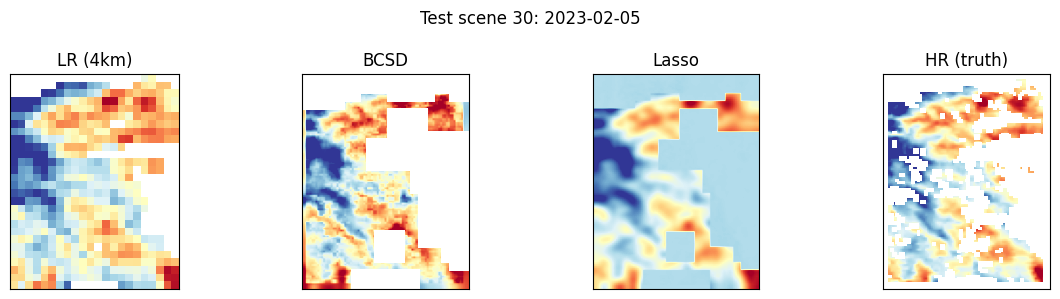

In [23]:
import matplotlib.pyplot as plt
i = 30  # pick a test scene
H, W = train_ds.hr_shape
gt = test['hr'][i]; m = test['mask'][i]
panels = [('LR (4km)',   test['lr'][i]),
          ('BCSD',       bc_test[i]),
          ('Lasso',      la_test[i]),
          ('HR (truth)', gt)]
vmin, vmax = np.nanpercentile(gt[m], 1), np.nanpercentile(gt[m], 99)
fig, axes = plt.subplots(1, len(panels), figsize=(3*len(panels), 3))
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Test scene {i}: {test['dates'][i]}")
plt.tight_layout(); plt.show()